# Potent_null free inter

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [2]:

import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin
from tools.viz.rc_style import rc_context_talk


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [3]:
data_dir='/data/bnd-data/raw/'

SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_17_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_24_15_00",
    "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


session=SESSIONS[0]

In [4]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

In [5]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    std=0.03
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)


In [269]:
def build_pseudo_trials(td_rows, chunk_size, fields):
    """Slice each row into non-overlapping chunks of `chunk_size` bins."""
    rows = []
    for _, trial in td_rows.iterrows():
        n_bins  = trial[fields[0]].shape[0]
        n_chunks = n_bins // chunk_size
        for k in range(n_chunks):
            sl = slice(k * chunk_size, (k + 1) * chunk_size)
            chunk = {}
            valid = True
            for f in fields:
                arr = trial[f][sl]
                if np.isnan(arr).any():
                    valid = False
                    break
                chunk[f] = arr
            if valid:
                rows.append(chunk)
    return pd.DataFrame(rows)

AREAS = Params.areas
WINDOW = (200, 450)
CHUNK_SIZE = WINDOW[1] - WINDOW[0]      # 250 bins — same as analysis window
fields_needed = ['MOp_rates_pca', 'bhv'] + [f'{a}_rates_pca' for a in AREAS]

print("trial_name counts in df_:")
print(df_.trial_name.value_counts().to_string())
print()

# --- Split df_ (pre-PCA) by condition, fit PCA separately on each ---
df_free_rows_raw = df_[~df_.trial_name.isin(['trial', 'intertrial'])]
if len(df_free_rows_raw) == 0:
    df_free_rows_raw = df_.iloc[[0]]
    print(f"No non-trial/intertrial rows found; using first row (trial_name='{df_.iloc[0].trial_name}')")
else:
    df_free_rows_raw = df_free_rows_raw.iloc[[0]]

df_it_raw = pyal.select_trials(df_, df_.trial_name == 'intertrial')

print("Fitting PCA on free locomotion rows...")
df_free_pca = dt.add_pca_df(df_free_rows_raw.copy())
df_free_pca = dt.add_bhv(df_free_pca, bhv_fields=Params.oscillating_key_points)

print("Fitting PCA on intertrial rows...")
df_it_pca = dt.add_pca_df(df_it_raw.copy())
df_it_pca = dt.add_bhv(df_it_pca, bhv_fields=Params.oscillating_key_points)

free_td = build_pseudo_trials(df_free_pca, CHUNK_SIZE, fields_needed)
print(f"Free loco source rows : {len(df_free_pca)}  →  pseudo-trials: {len(free_td)}")

intertrial_td = build_pseudo_trials(df_it_pca, CHUNK_SIZE, fields_needed)
print(f"Intertrial source rows: {len(df_it_pca)}  →  pseudo-trials: {len(intertrial_td)}")

z_cols = np.arange(2, len(Params.oscillating_key_points) * 3, 3)   # z-dim indices in bhv

def trial_mean_speed(td_row):
    vel_z = np.diff(td_row['bhv'][:, z_cols], axis=0)  # (T-1, 12)
    return np.mean(np.linalg.norm(vel_z, axis=1))

sf_ext = np.array([trial_mean_speed(r) for _, r in free_td.iterrows()])
si_ext = np.array([trial_mean_speed(r) for _, r in intertrial_td.iterrows()])

# Compute immobility threshold: p=5 percentile of combined speed distribution
thresh_imm = np.percentile(np.concatenate([sf_ext, si_ext]), 5)
print(f"Immobility threshold (p=5): {thresh_imm:.3f}")

free_td_ext       = free_td[sf_ext >= thresh_imm].reset_index(drop=True)
intertrial_td_ext = intertrial_td[si_ext >= thresh_imm].reset_index(drop=True)
print(f"After immobile filter (thresh={thresh_imm:.3f}): Free={len(free_td_ext)}, IT={len(intertrial_td_ext)}")

N_PSEUDO = min(len(free_td_ext), len(intertrial_td_ext))
print(f"\nBalancing to {N_PSEUDO} pseudo-trials per condition")

N_EXT = min(len(free_td_ext), len(intertrial_td_ext), N_PSEUDO)
print(f"Balancing to N={N_EXT} pseudo-trials")

free_td_ext_shuff       = free_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)
intertrial_td_ext_shuff = intertrial_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)

trial_name counts in df_:
trial_name
intertrial    500
trial         500
free            2

Fitting PCA on free locomotion rows...
Fitting PCA on intertrial rows...
Free loco source rows : 1  →  pseudo-trials: 192
Intertrial source rows: 500  →  pseudo-trials: 502
Immobility threshold (p=5): 1.962
After immobile filter (thresh=1.962): Free=188, IT=471

Balancing to 188 pseudo-trials per condition
Balancing to N=188 pseudo-trials


In [7]:
bhv_fields=['left_elbow', 'left_paw']
bhv_fields = Params.oscillating_key_points

In [14]:
#### Duplicated cell, take the first intertrials pseudo trials to match the free pseudotrials

def build_pseudo_trials(td_rows, chunk_size, fields):
    """Slice each row into non-overlapping chunks of `chunk_size` bins."""
    rows = []
    for _, trial in td_rows.iterrows():
        n_bins  = trial[fields[0]].shape[0]
        n_chunks = n_bins // chunk_size
        for k in range(n_chunks):
            sl = slice(k * chunk_size, (k + 1) * chunk_size)
            chunk = {}
            valid = True
            for f in fields:
                arr = trial[f][sl]
                if np.isnan(arr).any():
                    valid = False
                    break
                chunk[f] = arr
            if valid:
                rows.append(chunk)
    return pd.DataFrame(rows)

AREAS = Params.areas
WINDOW = (200, 450)
CHUNK_SIZE = WINDOW[1] - WINDOW[0]      # 250 bins — same as analysis window
fields_needed = ["MOp_rates_pca", "bhv"] + [f"{a}_rates_pca" for a in AREAS]

# --- Parameters ---
INTERTRIAL_ELAPSED_MIN = 45   # elapsed clock time budget for intertrial selection (minutes). None = match free duration
JOINT_PCA = False              # True: fit PCA on free + intertrial combined; False: fit separately per condition

print("trial_name counts in df_:")
print(df_.trial_name.value_counts().to_string())
print()

# --- Free locomotion rows ---
df_free_rows_raw = df_[~df_.trial_name.isin(["trial", "intertrial"])]
if len(df_free_rows_raw) == 0:
    df_free_rows_raw = df_.iloc[[0]]
    print(f"No non-trial/intertrial rows found; using first row (trial_name='{df_.iloc[0].trial_name}')")
else:
    df_free_rows_raw = df_free_rows_raw.iloc[[0]]

# Duration of the free period in seconds (10 ms bins)
ref_signal = "MOp_rates"
free_n_bins = df_free_rows_raw[ref_signal].iloc[0].shape[0]
free_bin_size = df_free_rows_raw["bin_size"].iloc[0]
free_duration_s = free_n_bins * free_bin_size
print(f"Free period duration: {free_duration_s:.1f} s ({free_duration_s/60:.1f} min)")

# Elapsed time budget for intertrial selection
if INTERTRIAL_ELAPSED_MIN is None:
    elapsed_budget_s = free_duration_s
    print(f"Using free duration as elapsed budget: {elapsed_budget_s:.1f} s")
else:
    elapsed_budget_s = INTERTRIAL_ELAPSED_MIN * 60
    print(f"Using specified elapsed budget: {elapsed_budget_s:.1f} s ({INTERTRIAL_ELAPSED_MIN} min)")

# --- Intertrial rows: keep those within elapsed_budget_s of clock time
#     after the free period ends, counting trial + intertrial rows together ---
free_pos = df_.index.get_indexer([df_free_rows_raw.index[0]])[0]
post_free = df_.iloc[free_pos + 1:]

all_durations = post_free[ref_signal].apply(lambda x: x.shape[0]) * post_free["bin_size"]
all_cum_time = all_durations.cumsum().values   # clock time from end of free period

it_mask = (post_free.trial_name == "intertrial").values
it_clock_times = all_cum_time[it_mask]         # clock time at end of each intertrial row

df_it_raw_full = pyal.select_trials(df_, df_.trial_name == "intertrial")
keep = it_clock_times <= elapsed_budget_s
df_it_raw = df_it_raw_full.iloc[:keep.sum()].reset_index(drop=True)

elapsed_it = it_clock_times[keep.sum() - 1] if keep.sum() > 0 else 0
print(f"Intertrial rows within {elapsed_budget_s:.1f} s of clock time: {len(df_it_raw)} / {len(df_it_raw_full)} (clock elapsed: {elapsed_it:.1f} s)")

# --- PCA: joint or separate ---
print(f"PCA mode: {'joint' if JOINT_PCA else 'separate'}")
if JOINT_PCA:
    df_combined = pd.concat([df_free_rows_raw, df_it_raw], ignore_index=True)
    df_combined_pca = dt.add_pca_df(df_combined.copy())
    df_free_pca = df_combined_pca.iloc[:len(df_free_rows_raw)].reset_index(drop=True)
    df_it_pca   = df_combined_pca.iloc[len(df_free_rows_raw):].reset_index(drop=True)
else:
    df_free_pca = dt.add_pca_df(df_free_rows_raw.copy())
    df_it_pca   = dt.add_pca_df(df_it_raw.copy())

df_free_pca = dt.add_bhv(df_free_pca, bhv_fields=bhv_fields)
df_it_pca   = dt.add_bhv(df_it_pca,   bhv_fields=bhv_fields)

free_td = build_pseudo_trials(df_free_pca, CHUNK_SIZE, fields_needed)
print(f"Free loco source rows : {len(df_free_pca)}  ->  pseudo-trials: {len(free_td)}")

intertrial_td = build_pseudo_trials(df_it_pca, CHUNK_SIZE, fields_needed)
print(f"Intertrial source rows: {len(df_it_pca)}  ->  pseudo-trials: {len(intertrial_td)}")

z_cols = np.arange(2, len(bhv_fields) * 3, 3)   # z-dim indices in bhv

def trial_mean_speed(td_row):
    vel_z = np.diff(td_row["bhv"][:, z_cols], axis=0)  # (T-1, 12)
    return np.mean(np.linalg.norm(vel_z, axis=1))

sf_ext = np.array([trial_mean_speed(r) for _, r in free_td.iterrows()])
si_ext = np.array([trial_mean_speed(r) for _, r in intertrial_td.iterrows()])

# Compute immobility threshold: p=5 percentile of combined speed distribution
thresh_imm = np.percentile(np.concatenate([sf_ext, si_ext]), 5)
print(f"Immobility threshold (p=5): {thresh_imm:.3f}")

free_td_ext       = free_td[sf_ext >= thresh_imm].reset_index(drop=True)
intertrial_td_ext = intertrial_td[si_ext >= thresh_imm].reset_index(drop=True)
print(f"After immobile filter (thresh={thresh_imm:.3f}): Free={len(free_td_ext)}, IT={len(intertrial_td_ext)}")

N_PSEUDO = min(len(free_td_ext), len(intertrial_td_ext))
print(f"Balancing to {N_PSEUDO} pseudo-trials per condition")

N_EXT = min(len(free_td_ext), len(intertrial_td_ext), N_PSEUDO)
print(f"Balancing to N={N_EXT} pseudo-trials")

free_td_ext_shuff       = free_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)
intertrial_td_ext_shuff = intertrial_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)


trial_name counts in df_:
trial_name
intertrial    500
trial         500
free            2

Free period duration: 480.0 s (8.0 min)
Using specified elapsed budget: 2700.0 s (45 min)
Intertrial rows within 2700.0 s of clock time: 301 / 500 (clock elapsed: 2691.0 s)
PCA mode: separate
Free loco source rows : 1  ->  pseudo-trials: 192
Intertrial source rows: 301  ->  pseudo-trials: 295
Immobility threshold (p=5): 2.185
After immobile filter (thresh=2.185): Free=188, IT=274
Balancing to 188 pseudo-trials per condition
Balancing to N=188 pseudo-trials


In [9]:
#### Duplicated cell, take all intertrial pseudo trials

def build_pseudo_trials(td_rows, chunk_size, fields):
    """Slice each row into non-overlapping chunks of `chunk_size` bins."""
    rows = []
    for _, trial in td_rows.iterrows():
        n_bins  = trial[fields[0]].shape[0]
        n_chunks = n_bins // chunk_size
        for k in range(n_chunks):
            sl = slice(k * chunk_size, (k + 1) * chunk_size)
            chunk = {}
            valid = True
            for f in fields:
                arr = trial[f][sl]
                if np.isnan(arr).any():
                    valid = False
                    break
                chunk[f] = arr
            if valid:
                rows.append(chunk)
    return pd.DataFrame(rows)

AREAS = Params.areas
WINDOW = (200, 450)
CHUNK_SIZE = WINDOW[1] - WINDOW[0]      # 250 bins — same as analysis window
fields_needed = ["MOp_rates_pca", "bhv"] + [f"{a}_rates_pca" for a in AREAS]

# --- Parameters ---
# All intertrial rows used — no time filtering
JOINT_PCA = False              # True: fit PCA on free + intertrial combined; False: fit separately per condition

print("trial_name counts in df_:")
print(df_.trial_name.value_counts().to_string())
print()

# --- Free locomotion rows ---
df_free_rows_raw = df_[~df_.trial_name.isin(["trial", "intertrial"])]
if len(df_free_rows_raw) == 0:
    df_free_rows_raw = df_.iloc[[0]]
    print(f"No non-trial/intertrial rows found; using first row (trial_name='{df_.iloc[0].trial_name}')")
else:
    df_free_rows_raw = df_free_rows_raw.iloc[[0]]

# Duration of the free period in seconds (10 ms bins)
ref_signal = "MOp_rates"
free_n_bins = df_free_rows_raw[ref_signal].iloc[0].shape[0]
free_bin_size = df_free_rows_raw["bin_size"].iloc[0]
free_duration_s = free_n_bins * free_bin_size
print(f"Free period duration: {free_duration_s:.1f} s ({free_duration_s/60:.1f} min)")

df_it_raw = pyal.select_trials(df_, df_.trial_name == "intertrial").reset_index(drop=True)
print(f"Using all {len(df_it_raw)} intertrial rows")

# --- PCA: joint or separate ---
print(f"PCA mode: {'joint' if JOINT_PCA else 'separate'}")
if JOINT_PCA:
    df_combined = pd.concat([df_free_rows_raw, df_it_raw], ignore_index=True)
    df_combined_pca = dt.add_pca_df(df_combined.copy())
    df_free_pca = df_combined_pca.iloc[:len(df_free_rows_raw)].reset_index(drop=True)
    df_it_pca   = df_combined_pca.iloc[len(df_free_rows_raw):].reset_index(drop=True)
else:
    df_free_pca = dt.add_pca_df(df_free_rows_raw.copy())
    df_it_pca   = dt.add_pca_df(df_it_raw.copy())

df_free_pca = dt.add_bhv(df_free_pca, bhv_fields=bhv_fields)
df_it_pca   = dt.add_bhv(df_it_pca,   bhv_fields=bhv_fields)

free_td = build_pseudo_trials(df_free_pca, CHUNK_SIZE, fields_needed)
print(f"Free loco source rows : {len(df_free_pca)}  ->  pseudo-trials: {len(free_td)}")

intertrial_td = build_pseudo_trials(df_it_pca, CHUNK_SIZE, fields_needed)
print(f"Intertrial source rows: {len(df_it_pca)}  ->  pseudo-trials: {len(intertrial_td)}")

z_cols = np.arange(2, len(bhv_fields) * 3, 3)   # z-dim indices in bhv

def trial_mean_speed(td_row):
    vel_z = np.diff(td_row["bhv"][:, z_cols], axis=0)  # (T-1, 12)
    return np.mean(np.linalg.norm(vel_z, axis=1))

sf_ext = np.array([trial_mean_speed(r) for _, r in free_td.iterrows()])
si_ext = np.array([trial_mean_speed(r) for _, r in intertrial_td.iterrows()])

# Compute immobility threshold: p=5 percentile of combined speed distribution
thresh_imm = np.percentile(np.concatenate([sf_ext, si_ext]), 5)
print(f"Immobility threshold (p=5): {thresh_imm:.3f}")

free_td_ext       = free_td[sf_ext >= thresh_imm].reset_index(drop=True)
intertrial_td_ext = intertrial_td[si_ext >= thresh_imm].reset_index(drop=True)
print(f"After immobile filter (thresh={thresh_imm:.3f}): Free={len(free_td_ext)}, IT={len(intertrial_td_ext)}")

free_td_ext_shuff       = free_td_ext.reset_index(drop=True)
intertrial_td_ext_shuff = intertrial_td_ext.reset_index(drop=True)
print(f"Free={len(free_td_ext_shuff)}, IT={len(intertrial_td_ext_shuff)} pseudo-trials (no balancing)")


trial_name counts in df_:
trial_name
intertrial    500
trial         500
free            2

Free period duration: 480.0 s (8.0 min)
Using all 500 intertrial rows
PCA mode: separate
Free loco source rows : 1  ->  pseudo-trials: 192
Intertrial source rows: 500  ->  pseudo-trials: 502
Immobility threshold (p=5): 1.962
After immobile filter (thresh=1.962): Free=188, IT=471
Free=188, IT=471 pseudo-trials (no balancing)


In [15]:
pc_dict = {
    "MOp": 30,
    "SSp": 30,
    "CP": 30,
    "VAL": 40,
}
for area_a in Params.areas:
    for area_b in Params.areas:
        if area_b == area_a:
            continue
        

        intertrial_td_ext_shuff = subspaces.compute_potent_null_td(
            td_=intertrial_td_ext_shuff,
            signal_x=f'{area_a}_rates_pca',
            signal_y=f'{area_b}_rates_pca',
            origin_rank=pc_dict[area_a],
            target_rank=pc_dict[area_b],
            n_iter=2,
            fit_rank=True,
            rank=10,
            window=(0, 250),
            thresh=0.05
        )
        # free_td_ext_shuff = subspaces.compute_potent_null_td(
        #     td_=free_td_ext_shuff,
        #     signal_x=f'{area_a}_rates_pca',
        #     signal_y=f'{area_b}_rates_pca',
        #     origin_rank=pc_dict[area_a],
        #     target_rank=pc_dict[area_b],
        #     n_iter=2,
        #     fit_rank=True,
        #     rank=10,
        #     window=(0, 250),
        #     thresh=0.01
        # )

Computing MOp_rates_pca -> SSp_rates_pca potent and null subspaces
Prediction R2 = 0.2389. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0580
	Iter: 2. Prediction R2 = 0.0015
Iteration number: 2. R2 below 0.05, breaking
	Final Prediction R2 = 0.0015
Diagnostics:
	Total MOp_rates_pca var:         17334.79
	Fraction Potent (dim: 10) var:    0.296
	Fraction Null (dim: 10) var:      0.155
	Fraction Null init var:          0.378
	Fraction MOp_rates_pca var:      0.674
Computing MOp_rates_pca -> CP_rates_pca potent and null subspaces
Prediction R2 = 0.2196. Optimal rank: 10
Using 2 iterations...
	Iter: 1. Prediction R2 = 0.0482
Iteration number: 1. R2 below 0.05, breaking
	Final Prediction R2 = 0.0482
Diagnostics:
	Total MOp_rates_pca var:         17334.79
	Fraction Potent (dim: 10) var:    0.270
	Fraction Null init var:          0.404
	Fraction MOp_rates_pca var:      0.674
Computing MOp_rates_pca -> VAL_rates_pca potent and null subspaces
Prediction R2 = 0.2098. Optima

In [18]:
intertrial_td_ext_shuff_vm = subspaces.match_null_variance_to_potent(intertrial_td_ext_shuff, Params.areas)
# free_td_ext_shuff = subspaces.match_null_variance_to_potent(free_td_ext_shuff, Params.areas)

MOp -> SSp: null var (2688.3) <= potent var (5134.3), skipping
MOp -> CP: null var 7006.8 -> 4807.3 (potent: 4683.6) | dims 20 -> 11
MOp -> VAL: null var 7068.3 -> 4741.7 (potent: 4622.1) | dims 20 -> 10
SSp -> MOp: null var 6351.5 -> 3207.2 (potent: 3335.5) | dims 22 -> 7
SSp -> CP: null var 6829.3 -> 3023.2 (potent: 2857.7) | dims 22 -> 5
SSp -> VAL: null var 6330.4 -> 3391.2 (potent: 3356.5) | dims 22 -> 9
CP -> MOp: null var 4519.8 -> 2569.0 (potent: 2663.9) | dims 20 -> 9
CP -> SSp: null var 4500.7 -> 2604.8 (potent: 2683.0) | dims 20 -> 9
CP -> VAL: null var 4852.7 -> 2323.0 (potent: 2331.0) | dims 22 -> 8
VAL -> MOp: null var 10460.1 -> 7322.1 (potent: 7243.2) | dims 28 -> 18
VAL -> SSp: null var 11233.6 -> 6384.8 (potent: 6469.7) | dims 30 -> 15
VAL -> CP: null var 12196.7 -> 5628.1 (potent: 5506.7) | dims 32 -> 12


In [19]:
def decode_r2(td, signal, n_pcs, bhv_n_cols, cv):
    X = np.stack(td[signal].values)
    n_trials, n_time, n_dims = X.shape
    X_flat = X.reshape(n_trials * n_time, n_dims)
    if n_pcs is not None:
        X_flat = X_flat[:, :n_pcs]
    y = np.stack(td.bhv.values).reshape(-1, bhv_n_cols)
    r2s = cross_val_score(Ridge(0.01), X_flat, y, cv=cv, scoring=vw_r2_scorer)
    return r2s.mean(), r2s.std()

bhv_n_cols = len(bhv_fields) * 3
cv = KFold(5, shuffle=False)
td = intertrial_td_ext_shuff_vm

results = {}   # (area_x, area_y) -> {full, potent, null}

for area_x in Params.areas:
    for area_y in Params.areas:
        if area_x == area_y:
            continue
        potent_col = f"{area_x}_rates_pca_potent_{area_y}_rates_pca"
        null_col   = f"{area_x}_rates_pca_null_{area_y}_rates_pca"
        if potent_col not in td.columns:
            continue

        r2_full   = decode_r2(td, f"{area_x}_rates_pca", pc_dict[area_x], bhv_n_cols, cv)
        r2_potent = decode_r2(td, potent_col, None, bhv_n_cols, cv)
        r2_null   = decode_r2(td, null_col,   None, bhv_n_cols, cv)

        results[(area_x, area_y)] = dict(full=r2_full, potent=r2_potent, null=r2_null)
        print(f"{area_x}->{area_y}  full={r2_full[0]:.3f}  potent={r2_potent[0]:.3f}  null={r2_null[0]:.3f}")



# print("\\nSummary:")
# for (ax_, ay), v in results.items():
#     print(f"{ax_}->{ay}: full={v[\'full\'][0]:.3f}±{v[\'full\'][1]:.3f}  potent={v[\'potent\'][0]:.3f}±{v[\'potent\'][1]:.3f}  null={v[\'null\'][0]:.3f}±{v[\'null\'][1]:.3f}\")


MOp->SSp  full=0.330  potent=0.284  null=0.041
MOp->CP  full=0.330  potent=0.261  null=0.138
MOp->VAL  full=0.330  potent=0.269  null=0.110
SSp->MOp  full=0.333  potent=0.287  null=0.113
SSp->CP  full=0.333  potent=0.224  null=0.124
SSp->VAL  full=0.333  potent=0.312  null=0.102
CP->MOp  full=0.273  potent=0.258  null=0.011
CP->SSp  full=0.273  potent=0.260  null=0.007
CP->VAL  full=0.273  potent=0.214  null=0.010
VAL->MOp  full=0.332  potent=0.304  null=0.073
VAL->SSp  full=0.332  potent=0.309  null=0.064
VAL->CP  full=0.332  potent=0.250  null=0.159


## Plotting

Saved: ../../results/pdfs/free_inter_frame1_full.pdf


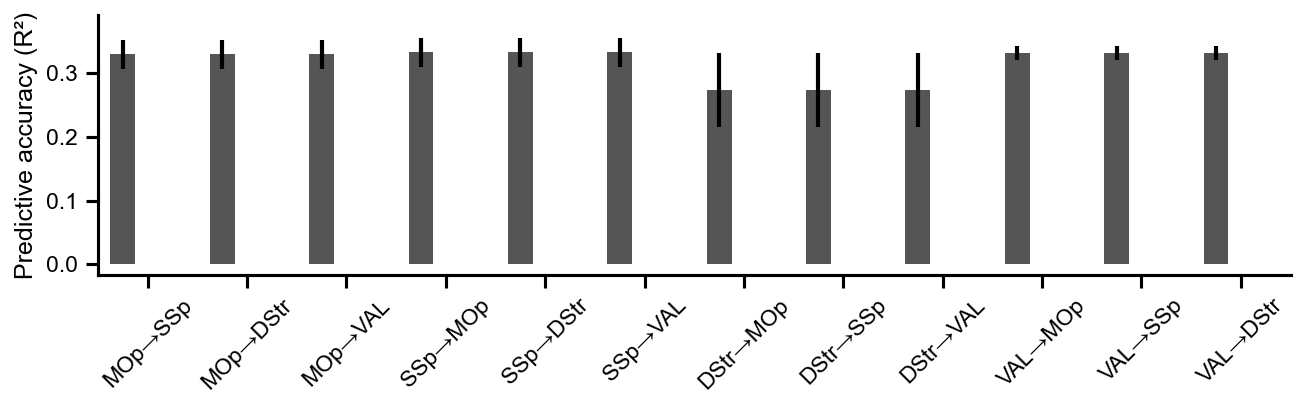

Saved: ../../results/pdfs/free_inter_frame2_shared.pdf


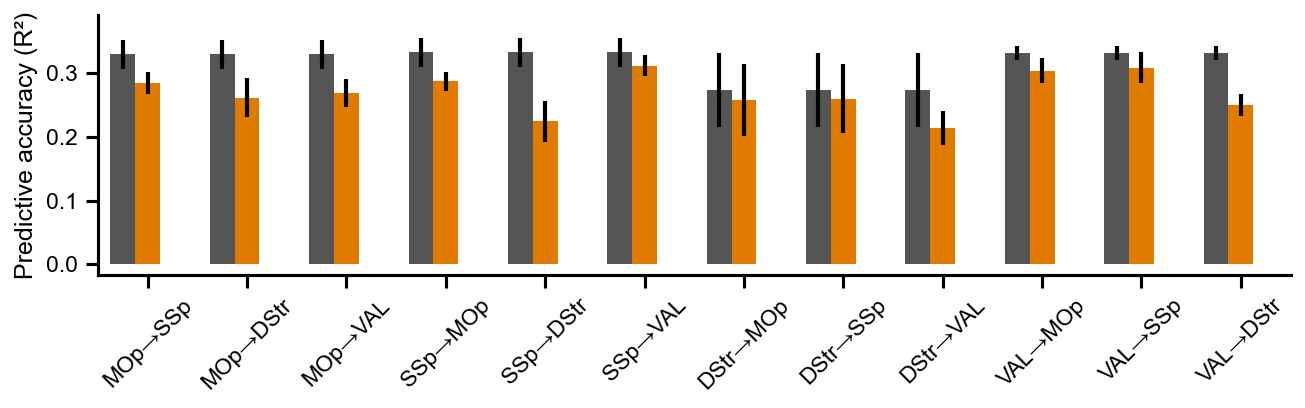

Saved: ../../results/pdfs/free_inter_frame3_private.pdf


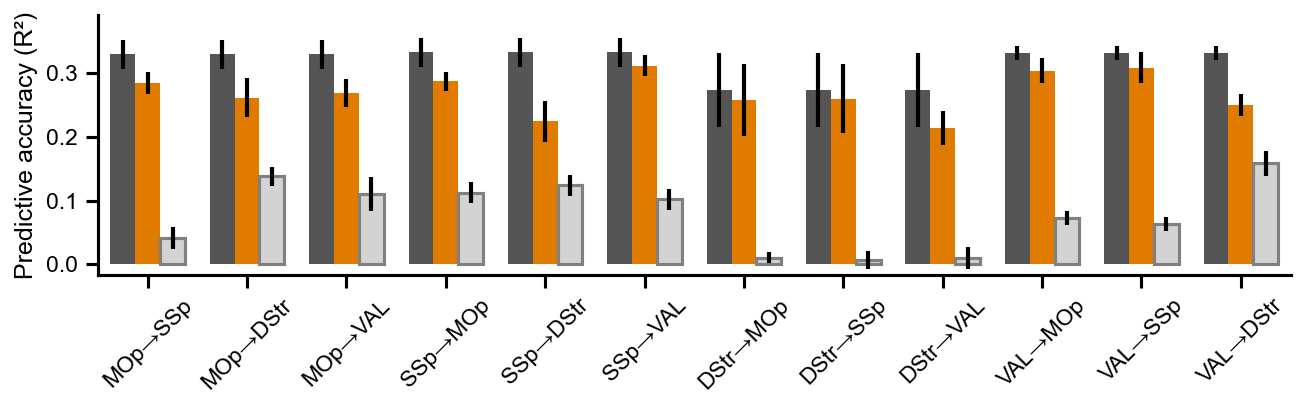

In [53]:
# --- Progressive reveal plots for presentation ---
import matplotlib as mpl
from pathlib import Path

C_FULL   = '#555555'
C_POTENT = '#e07b00'
C_NULL   = 'lightgray'

_rename  = {'CP': 'DStr'}
_PDF_DIR = Path('../../results/pdfs')

pairs  = list(results.keys())
labels = [f"{_rename.get(a,a)}→{_rename.get(b,b)}" for a, b in pairs]
x      = np.arange(len(pairs))
width  = 0.25

full_m   = np.array([results[p]["full"][0]   for p in pairs])
potent_m = np.array([results[p]["potent"][0] for p in pairs])
null_m   = np.array([results[p]["null"][0]   for p in pairs])
full_s   = np.array([results[p]["full"][1]   for p in pairs])
potent_s = np.array([results[p]["potent"][1] for p in pairs])
null_s   = np.array([results[p]["null"][1]   for p in pairs])

# fixed y-limits from the full data
_ymax = max(
    (full_m   + full_s).max(),
    (potent_m + potent_s).max(),
    (null_m   + null_s).max(),
) * 1.1
_ymin = min(0, (null_m - null_s).min()) - 0.01
_ylim = (_ymin, _ymax)

_bars = [
    (x - width, full_m,   full_s,   C_FULL,   'Full',    'none',  'free_inter_frame1_full'),
    (x,         potent_m, potent_s, C_POTENT, 'Shared',  'none',  'free_inter_frame2_shared'),
    (x + width, null_m,   null_s,   C_NULL,   'Private', 'gray',  'free_inter_frame3_private'),
]

for n_shown in [1, 2, 3]:
    save_name = _bars[n_shown - 1][6]

    with rc_context_talk():
        fig, ax = plt.subplots(figsize=(max(6, len(pairs) * 0.75), 3))

        for xpos, means, stds, color, lbl, ec, _ in _bars[:n_shown]:
            ax.bar(xpos, means, width, yerr=stds, color=color,
                   capsize=0, label=lbl, edgecolor=ec)

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45)
        ax.set_ylabel('Predictive accuracy (R²)')
        ax.set_ylim(_ylim)

        # keep x-axis width identical across frames
        ax.set_xlim(x[0] - width * 2, x[-1] + width * 2)

        fig.tight_layout()

        out = _PDF_DIR / f'{save_name}.pdf'
        fig.savefig(out, bbox_inches='tight')
        print(f'Saved: {out}')

        plt.show()

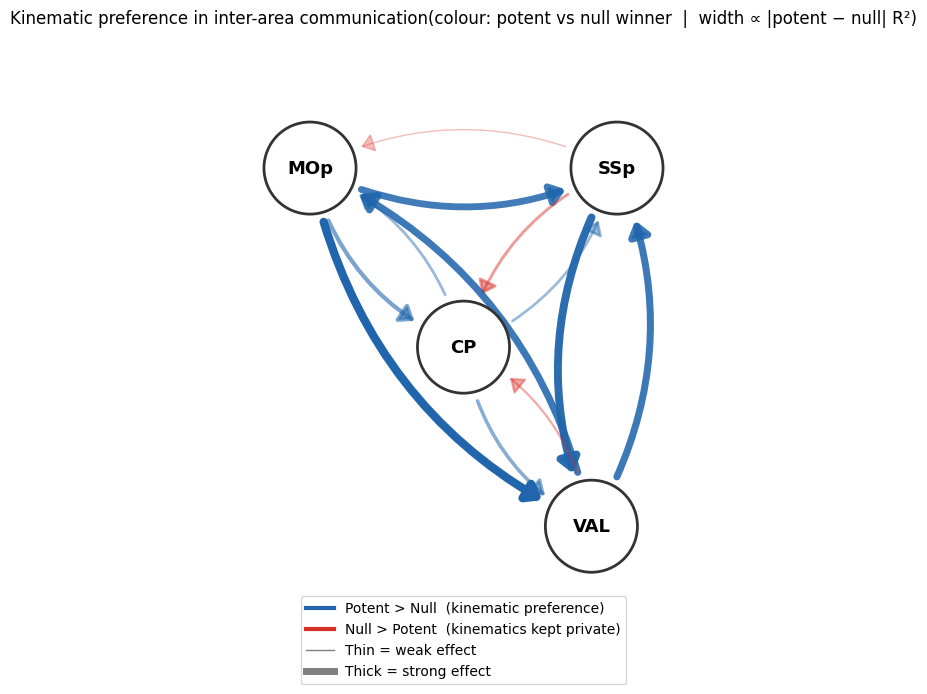

potent − null R² (sorted):
  >>  MOp->VAL: +0.362
  >>  SSp->VAL: +0.341
  >>  VAL->MOp: +0.301
  >>  VAL->SSp: +0.301
  >>  MOp->SSp: +0.292
  >>  MOp->CP: +0.167
  >>  CP->VAL: +0.137
  >>  CP->MOp: +0.100
  >>  CP->SSp: +0.096
  <<  SSp->MOp: -0.033
  <<  VAL->CP: -0.074
  <<  SSp->CP: -0.106


In [264]:
# Flow diagram: kinematic preference in inter-area communication

import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.lines import Line2D

diff_dict = {
    (ax_, ay): v["potent"][0] - v["null"][0]
    for (ax_, ay), v in results.items()
}
max_abs = max(abs(d) for d in diff_dict.values())

# Custom layout
pos = {
    "MOp": np.array([-0.6,  0.7]),
    "SSp": np.array([ 0.6,  0.7]),
    "CP":  np.array([ 0.0,  0.0]),
    "VAL": np.array([ 0.5, -0.7]),
}

COL_KIN  = "#2166ac"
COL_PRIV = "#d73027"
NODE_R   = 0.18
SHRINK   = 40

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axis("off")

# --- Arrows ---
for (ax_, ay), diff in diff_dict.items():
    lw    = 0.5 + 5.5 * abs(diff) / max_abs
    alpha = 0.25 + 0.75 * abs(diff) / max_abs
    color = COL_KIN if diff > 0 else COL_PRIV

    arrow = FancyArrowPatch(
        posA=pos[ax_], posB=pos[ay],
        arrowstyle=mpatches.ArrowStyle("-|>", head_width=6, head_length=8),
        connectionstyle="arc3,rad=0.25",
        linewidth=lw,
        color=color,
        alpha=alpha,
        shrinkA=SHRINK, shrinkB=SHRINK,
        mutation_scale=1,
        zorder=2,
    )
    ax.add_patch(arrow)

# --- Nodes ---
for area, p in pos.items():
    circ = Circle(p, NODE_R, color="white", ec="#333333", linewidth=2, zorder=3)
    ax.add_patch(circ)
    ax.text(p[0], p[1], area, ha="center", va="center",
            fontsize=13, fontweight="bold", zorder=4)

# --- Legend ---
legend_elements = [
    Line2D([0], [0], color=COL_KIN,  linewidth=3, label="Potent > Null  (kinematic preference)"),
    Line2D([0], [0], color=COL_PRIV, linewidth=3, label="Null > Potent  (kinematics kept private)"),
    Line2D([0], [0], color="grey",   linewidth=1, label="Thin = weak effect"),
    Line2D([0], [0], color="grey",   linewidth=5, label="Thick = strong effect"),
]
ax.legend(handles=legend_elements, loc="lower center",
          bbox_to_anchor=(0.5, -0.06), frameon=True, fontsize=10)

ax.set_title(
    "Kinematic preference in inter-area communication"
    "(colour: potent vs null winner  |  width ∝ |potent − null| R²)",
    fontsize=12, pad=12
)

plt.tight_layout()
plt.show()

print("potent − null R² (sorted):")
for (ax_, ay), diff in sorted(diff_dict.items(), key=lambda x: -x[1]):
    marker = ">>" if diff > 0 else "<<"
    print(f"  {marker}  {ax_}->{ay}: {diff:+.3f}")
